In [1]:
import torch
import pandas as pd
import numpy as np
import torchvision.transforms as Tr
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from io import StringIO
import napari
from tkinter import filedialog as fd
from scipy.optimize import curve_fit
from matplotlib import pyplot as plt
import nibabel as nib
import matplotlib as mpl
from skimage.exposure import match_histograms
from nilearn import image
from nilearn import plotting
from scipy.ndimage import gaussian_filter
import math
import matplotlib.patches as patches

In [ ]:
def mask(seg, val):
    #To extract individual tissue from segmentation nib file
    binary_mask = np.where(seg == val, 1, 0) # Integer Mask
    return binary_mask

#dataset 1
"""
seg_loc = "/Users/pi58/Library/CloudStorage/Box-Box/PhD/Datasets/ExBox3/T1_brain_pveseg.nii.gz"
csf_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/Datasets/ExBox3/T1_brain_pve_0.nii.gz")
gm_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/Datasets/ExBox3/T1_brain_pve_1.nii.gz")
wm_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/Datasets/ExBox3/T1_brain_pve_2.nii.gz")
img_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/Datasets/ExBox3/T1_brain.nii.gz")
seg = nib.load(seg_loc).get_fdata()
"""

#dataset 2
"""
seg_loc = "/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_pveseg.nii.gz"
csf_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_pve_0.nii.gz")
gm_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_pve_1.nii.gz")
wm_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_pve_2.nii.gz")
img_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_restore.nii.gz") #Can use either bias corrected or brain extracted version here
seg = nib.load(seg_loc).get_fdata()
"""


#IXI sample 102
"""
seg_loc = "/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Hulf_Synth/Data/ixi/T1/102/registration/fast_pveseg.nii.gz"
csf_nib = nib.load("./Data/ixi/T1/102/registration/fast_pve_0.nii.gz")
gm_nib = nib.load("./Data/ixi/T1/102/registration/fast_pve_1.nii.gz")
wm_nib = nib.load("./Data/ixi/T1/102/registration/fast_pve_2.nii.gz")
img_nib = nib.load("./Data/ixi/T1/102/registration/fast_restore.nii.gz") #Can use either bias corrected or brain extracted version here
seg = nib.load(seg_loc).get_fdata()
"""

#Validation Data
seg_loc = "./Data/validation_data/ulf/fast_seg.nii.gz"
csf_nib = nib.load("./Data/validation_data/ulf/fast_pve_0.nii.gz")
gm_nib = nib.load("./Data/validation_data/ulf/fast_pve_1.nii.gz")
wm_nib = nib.load("./Data/validation_data/ulf/fast_pve_2.nii.gz")
img_nib = nib.load("./Data/validation_data/ulf/fast_restore.nii.gz") #Can use either bias corrected or brain extracted version here
seg = nib.load(seg_loc).get_fdata()




#Extracting tissues
csf_masked = mask(seg,1)
gm_masked = mask(seg,2)
wm_masked = mask(seg,3)

csf = csf_masked  * img_nib.get_fdata() #* csf_nib.get_fdata()
gm = gm_masked  * img_nib.get_fdata() #* gm_nib.get_fdata()
wm = wm_masked  * img_nib.get_fdata() #* wm_nib.get_fdata()
hf = hf_img = csf + gm + wm

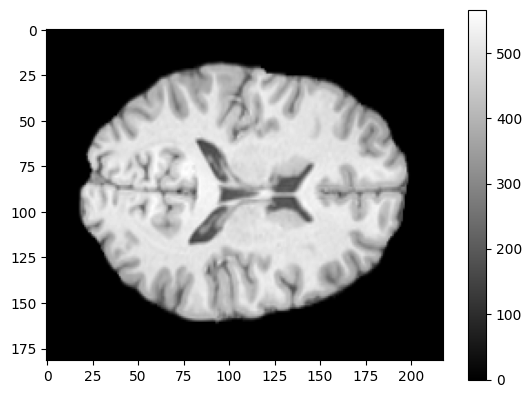

In [11]:
%matplotlib inline
slice_num = 90
plt.imshow(img_nib.get_fdata()[:,:,slice_num],cmap='gray')
plt.colorbar()
# plt.show()

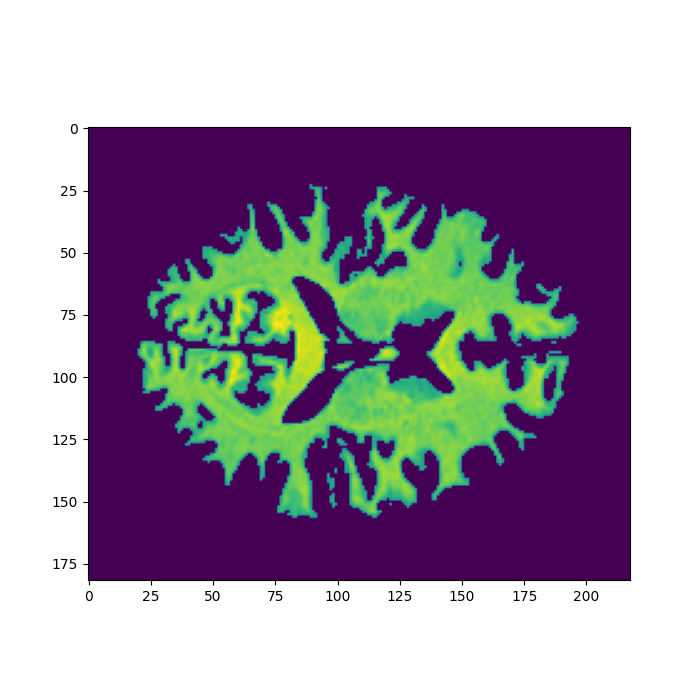

In [40]:
%matplotlib ipympl
# %matplotlib inline

import matplotlib.cbook as cbook
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from mpl_interactions import image_segmenter


im = Image.fromarray((wm*img_nib.get_fdata())[:,:,slice_num])
segmenter = image_segmenter(im, mask_colors="red", mask_alpha=0.76, figsize=(7, 7))
display(segmenter,colormaps='gray',colorbar=segmenter)


In [ ]:
#dataset = 1 #csf (119,82) (128,82) -> (119,85) (128,85) #gm (123, 77) (126, 79) -> (133,70) (135, 74)
#dataset = 2 #wm(135,106) (142,106) -> (135,103) (142, 103) #gm (43, 50) (47,50) -> (43, 46) (47, 46), #csf (64, 101) (83,101) -> (64,98) (83,98)

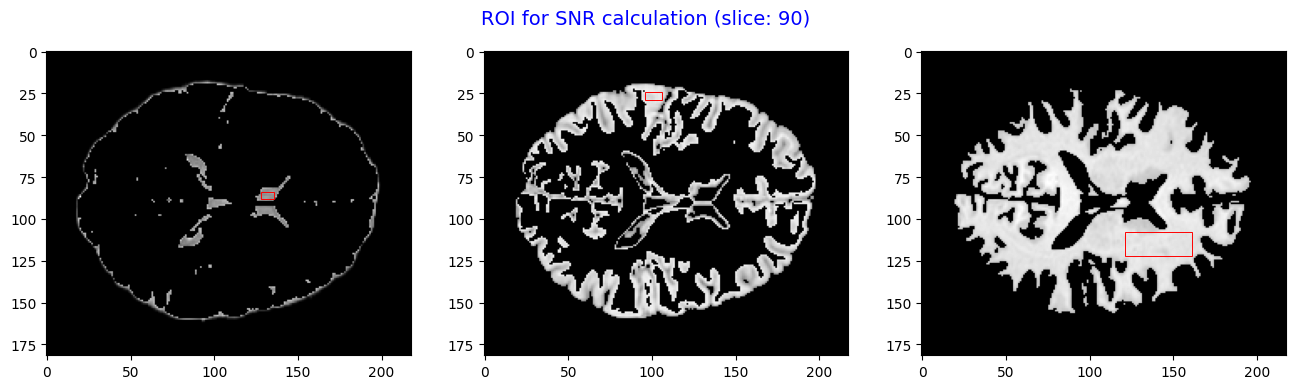

In [42]:
# %matplotlib inline
# %matplotlib ipympl

fig, axs = plt.subplots(1, 3, figsize=(16, 4))
im1 = axs[0].imshow((csf)[:,:,slice_num],cmap='gray')# ,vmax = 1000)
im2 = axs[1].imshow((gm)[:,:,slice_num],cmap='gray')#,vmax = 800)
im3 = axs[2].imshow((wm)[:,:,slice_num],cmap='gray')#,vmax = 600)


# rect3 = patches.Rectangle((55, 69), 5, 3, linewidth=1, edgecolor='r', facecolor='none') #ms 
rect0 = patches.Rectangle((128, 84), 8, 4, linewidth=0.7, edgecolor='r', facecolor='none') #csf 
rect1 = patches.Rectangle((96, 24), 10, 5, linewidth=0.7, edgecolor='r', facecolor='none') #gm 
rect2 = patches.Rectangle((121, 108), 40, 14, linewidth=0.7, edgecolor='r', facecolor='none') #wm

axs[0].add_patch(rect0)
axs[1].add_patch(rect1)
axs[2].add_patch(rect2)
# axs[3].add_patch(rect3)



fig.suptitle('ROI for SNR calculation'+ ' (slice: ' + str(slice_num) + ')', fontsize=14,color='blue')
plt.show()

In [54]:
#dataset = 1
# csf[82:86,119:128,95]
# gm[76:80, 123:128,95]
# wm[99:109,145:155,95]
# print(wm[99:109,145:155,95].mean(), gm[76:80, 123:128,95].mean(), csf[82:86,119:128,95].mean())

#dataset = 2
# print((wm)[105:110, 132:142, 95].mean(), (gm)[45:48,43:48,95].mean(), (csf)[96:101,70:80,95].mean())

329.27 188.25 64.0


In [54]:
#ixi sample = 102
# print(gm[24:29, 96:106, slice_num])
# print(wm[108:122, 121:161, slice_num])
print((csf)[84:88, 128:136, slice_num].mean(), gm[24:29, 96:106, slice_num].mean(), wm[108:122, 121:161, slice_num].mean())


190.82789182662964 398.17935974121093 503.3616425105504


In [87]:
# img_nib.get_fdata()[99:109,145:155,95][wm_nib.get_fdata()[99:109,145:155,95]>0.9]
img_nib.get_fdata()[108:122, 121:161, slice_num][wm_nib.get_fdata()[108:122, 121:161, slice_num]>0.9]

array([522.05859375, 519.96740723, 518.72399902, 510.60131836,
       504.43301392, 515.55633545, 515.94592285, 488.36169434,
       457.23327637, 460.78894043, 475.82003784, 478.92718506,
       480.0531311 , 477.72790527, 467.73376465, 467.91793823,
       482.88671875, 498.6053772 , 519.15710449, 529.64703369,
       518.39337158, 518.20904541, 513.34741211, 508.28823853,
       509.89038086, 507.68991089, 507.94641113, 509.72537231,
       512.27111816, 510.21334839, 501.68460083, 503.14981079,
       506.58947754, 502.7137146 , 504.18609619, 505.2046814 ,
       520.02496338, 519.25305176, 513.44482422, 505.76916504,
       501.34552002, 510.15945435, 525.5199585 , 525.48352051,
       496.63644409, 475.62985229, 478.57608032, 480.67166138,
       470.58929443, 476.84289551, 483.06091309, 475.38299561,
       473.08306885, 479.86300659, 491.02963257, 498.45178223,
       509.76544189, 512.71154785, 513.80450439, 516.03942871,
       509.16943359, 514.71478271, 513.51098633, 516.90

In [105]:
'''
#taking mean of only those samples which are 90% probabilistic
csf_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_pve_0.nii.gz")
gm_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_pve_1.nii.gz")
wm_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_pve_2.nii.gz")


wm_roi_pixels = img_nib.get_fdata()[105:110, 132:142, 95][wm_nib.get_fdata()[105:110, 132:142, 95]>0.9]
gm_roi_pixels = img_nib.get_fdata()[45:48,43:48,95][gm_nib.get_fdata()[45:48,43:48,95]>0.9]
csf_roi_pixels = img_nib.get_fdata()[96:101,70:80,95][csf_nib.get_fdata()[96:101,70:80,95]>0.9]

print(csf_roi_pixels.mean())
'''

Noise
- Loading raw image and computing BG nosie

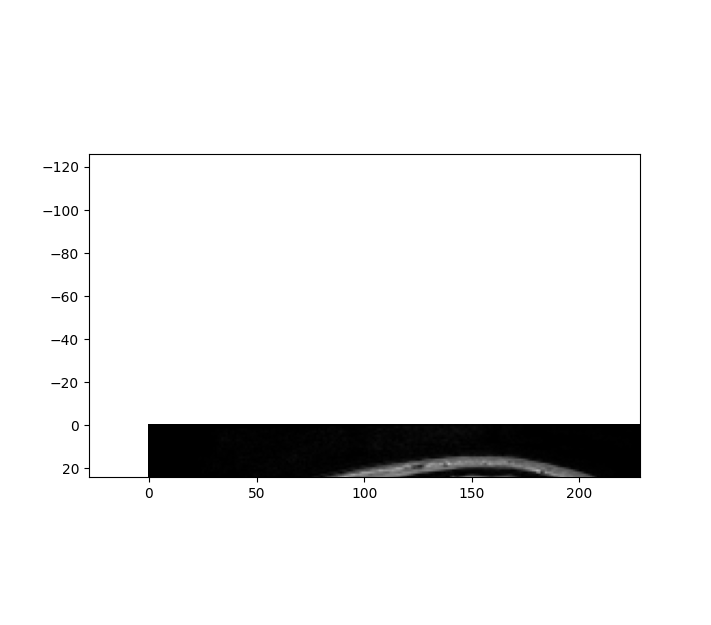

In [77]:
# %matplotlib ipympl
noise = nib.load("./Data/ixi/T1/102/raw.nii.gz")
plt.imshow(noise.get_fdata()[:,162,:].T, cmap='gray')
plt.show()

In [74]:
#ixi sample: 102
std_bg = noise.get_fdata()[:,163,:][55:79, 6:16, ].std() #region-1
# noise.get_fdata()[:,163,:][50:60,124:138, ].std() #region-2

5.173624347484933

In [103]:
#Noise for dataset = 2
noise = nib.load("./data_2/structural.nii.gz")
print("BG Noise in different regions :", noise.get_fdata()[:20,:20,95].std(), noise.get_fdata()[150:170,150:170,95].std(), noise.get_fdata()[155:,:25,95].std(), noise.get_fdata()[:25,150:170,95].std()) #Mean of all 4 regions in background
std_bg = noise.get_fdata()[:20,:20,95].std() #Background Noise extracted manually

BG Noise in different regions : 5.867293229716557 8.561372573231273 5.378807093419787 15.863190319041825


In [104]:
std_bg

5.867293229716557